<a href="https://colab.research.google.com/github/AhmadEgbaria1/deep-learning-project2/blob/main/Final1_DL_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning: Assignment #2
## Submission date: 24/12/2025, 23:59.
### Topics:
- Regularization
- Batch Normalization
- Convolutional Neural Networks
- Semantic Segmentation


**Submitted by:**

- Ahmad Egbaria
- Morad kutt


**Assignment Instructions:**

· Submissions are in **pairs only**. Write both names + IDs at the top of the notebook.

· Keep your code **clean, concise, and readable**.

· You may work in your IDE, but you **must** paste the final code back into the **matching notebook cells** and run it there.  


· <font color='red'>Write your textual answers in red.</font>  
(e.g., `<span style="color:red">your answer here</span>`)

· All figures, printed results, and outputs should remain visible in the notebook.  
Run **all cells** before submitting and **do not clear outputs**.

· Use relative paths — **no absolute file paths** pointing to local machines.

· **Important:** Your submission must be entirely your own.  
Any form of plagiarism (including uncredited use of ChatGPT or AI tools) will result in **grade 0** and disciplinary action.


In [ ]:
# --- Global Setup ---

# Import Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import itertools
import random
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn.init as init
from tqdm import tqdm
import os
from glob import glob
import pandas as pd
from PIL import Image
from google.colab import files
import zipfile


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Question 1: Convolutional Digit Classification on SVHN (25 Points)

In this question, our goal is to implement a Convolutional Neural Network (CNN) for image classification on the The Street View House Numbers (SVHN) Dataset. The dataset consists of read-world house number images.

**source:** http://ufldl.stanford.edu/housenumbers/

### Data Loading and Preprocessing

In this section we will load, explore and preprocess the dataset for training.

You are given the **SVHN** (Street View House Numbers) dataset: a collection of real-world images of digits (0–9) captured from house numbers in Google Street View. Each image is 32×32 pixels and contains three color channels (RGB). The goal is to classify each image into one of the 10 digit classes (0 – 9).

The dataset will be downloaded automatically to the local environment using the `torchvision.datasets.SVHN` class.

For this section, implement the preprocessing procedure and explain your choice, then create the loaders for the train and test sets.



In [ ]:
# We convert images to tensors and normalize them using the precomputed
# mean and standard deviation of the SVHN dataset. Normalization helps
# stabilize training and improves convergence. The same preprocessing
# is applied to train and test sets to ensure consistency.



transform = transforms.Compose([
    transforms.ToTensor(),
     transforms.Normalize((0.4377, 0.4438, 0.4728),
                         (0.1980, 0.2010, 0.1970))
])

# Load the SVHN Letters dataset
train_dataset = datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset  = datasets.SVHN(root='./data', split='test', download=True, transform=transform)

# Inspect the dataset
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

# Get one image and label
image, label = train_dataset[0]
print(f"Shape of one image: {image.shape} (C x H x W)")
print(f"Label of first image: {label}")

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

Number of training samples: 73257
Number of testing samples: 26032
Shape of one image: torch.Size([3, 32, 32]) (C x H x W)
Label of first image: 1


Finally, run the cell below to take a look at a few sample images to better understand the dataset we're working with.

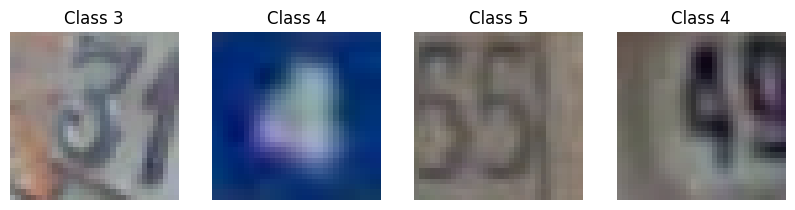

In [ ]:
images, labels = next(iter(train_loader))

# Show first 4 images
fig, axes = plt.subplots(1, 4, figsize=(10, 4))
for i in range(4):
  img = images[i].permute(1, 2, 0).numpy()
  img = np.clip(img * 0.229 + 0.485, 0, 1)  # unnormalize for display
  axes[i].imshow(img)
  axes[i].set_title(f"Class {labels[i].item()}")
  axes[i].axis('off')
plt.show()

**Answer the following Questions:**

<font color="red">1. How is SVHN fundamentally harder than MNIST?  
SVHN fundamentally harder than MNIST for many reasons such that:
1.image type: MNIST is scanned but SVHN is real world photos  

2.channels: MNIST is one channel(gray scale) but SVHN is whith 3 channels which makes it harder to make operations on it  
3.background: the background of MNIST is blak and clean but SVHN is in sevral colors and not clear   
4.illumination: the first one is unoform and the second isnt which make digit regozition harder  
5.noise:the first is much clear from noise from the second
and because of these diffrences it all make recogniztion of digits in SVHN much harder than MNIST
</font>  
   


<font color="red">2. Which preprocessing or architectural choices become necessary because of this difference?  

we need to do:
1.input normalization:Channel-wise normalization is necessary to handle variations in lighting and color across RGB channels and to stabilize training.  
2.use of CNN:they exploit spatial locality, are more robust to translations, and can learn hierarchical features that help distinguish digits from complex backgrounds.  
3.deeper architectures:SVHN typically requires deeper networks with multiple convolutional layers to capture increasingly abstract features, such as edges, shapes, and digit structures under clutter.  
4.pooling layers: ax-pooling or average-pooling layers help achieve translation invariance
these choices help us to delay with the SVHN problem
</font>


### CNN Architecture Design

We will design a convolutional neural network (inspired by AlexNet) for digit classification.
The network consists of **three convolutional feature-extraction stages**, followed by a **two-layer fully connected classifier**.

Your architecture must follow the structure below:

- Convolutional Layer with 32 output channels, kernel size = 3×3, stride = 1, padding = 1
- ReLU activation function
- MaxPooling Layer with a kernel size of 3×3 and a stride of 2

- Convolutional Layer with 64 output channels, kernel size = 3×3, stride = 1, padding = 1
- ReLU activation function.
- Convolutional Layer with 128 output channels, kernel size = 3×3, stride = 1, padding = 1

- ReLU activation function.

- MaxPooling Layer with a kernel size of 3×3 and a stride of 2.

- Dropout Layer  with a dropout probability of 0.5.

- Fully Connected Layer with output size of 128.

- ReLU activation function

- Dropout Layer  with a dropout probability of 0.5.

- Fully Connected Layer with output size of 10 (for the 10 digit classes, 0–9).



In [ ]:
# TODO: Define the CNN architecture

class SVHN_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Feature extractor
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.drop_feat = nn.Dropout(p=0.5)

        # For 32x32 input:
        # 32x32 -> pool(3,2) -> 13x13 -> pool(3,2) -> 6x6
        self.fc1 = nn.Linear(128 *7 * 7, 128)
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))

        x = F.relu(self.conv3(x))
        x = self.pool2(x)

        x = self.drop_feat(x)

        x = torch.flatten(x, 1)          # (N, 128*6*6)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)                  # (N, 10)
        return x



**Answer the following Questions:**

<font color="red">1. Which part(s) of your CNN most strongly influence receptive field size?  

The receptive field size is mainly influenced by the convolutional layers (kernel size and depth) and by pooling layers, especially their stride. Stacking multiple convolution and pooling layers causes neurons in deeper    layers to respond to increasingly larger regions of the input image.</font>   

<font color="red">2. Why does receptive field matter for recognizing digits embedded in cluttered scenes?  

Receptive field size is crucial in cluttered scenes because recognizing digits requires integrating spatially distant features while suppressing irrelevant background patterns.</font>


Now we will setup all training parameters and train the model.

Your tasks in this section are to create an instance of the model and choose and explain your choice of optimizer and loss function.
3. Fill the missing code in the training function.
4. Train the model for ~6 epochs on the training set (in colab CPU should take ~30 mins).

In [ ]:
model = SVHN_CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 2) train function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).long()

        # forward
        logits = model(images)
        loss = criterion(logits, labels)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # stats
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# 3) training loop (~6 epochs)
epochs = 6
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")


Epoch 1/6 | Train Loss: 1.0788 | Train Acc: 0.6455
Epoch 2/6 | Train Loss: 0.5812 | Train Acc: 0.8244
Epoch 3/6 | Train Loss: 0.4953 | Train Acc: 0.8519
Epoch 4/6 | Train Loss: 0.4429 | Train Acc: 0.8671
Epoch 5/6 | Train Loss: 0.4115 | Train Acc: 0.8780
Epoch 6/6 | Train Loss: 0.3865 | Train Acc: 0.8858


Now, fill in the missing code for the training function and train the model for 10 epochs.

In [ ]:
import torch
import torch.nn.functional as F

def train_model(model, train_loader, criterion, optimizer, device, num_epochs=10):
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            # 1) להעביר ל-GPU/CPU המתאים
            images = images.to(device)
            labels = labels.to(device)

            # 2) לאפס גרדיאנטים מהאיטרציה הקודמת
            optimizer.zero_grad()

            # 3) Forward: מודל נותן ניבויים (logits)
            outputs = model(images)

            # 4) לחשב loss
            loss = criterion(outputs, labels)

            # 5) Backward: לחשב גרדיאנטים
            loss.backward()

            # 6) עדכון משקלים
            optimizer.step()

            # 7) סטטיסטיקות (loss + accuracy)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")


In [ ]:
#TODO: Implement
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SVHN_CNN(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(model, train_loader, criterion, optimizer, device, num_epochs=10)


Epoch [1/10] Train Loss: 1.1082, Train Acc: 63.39%
Epoch [2/10] Train Loss: 0.6001, Train Acc: 81.77%
Epoch [3/10] Train Loss: 0.5126, Train Acc: 84.64%
Epoch [4/10] Train Loss: 0.4602, Train Acc: 86.19%
Epoch [5/10] Train Loss: 0.4310, Train Acc: 87.10%
Epoch [6/10] Train Loss: 0.4070, Train Acc: 87.96%
Epoch [7/10] Train Loss: 0.3921, Train Acc: 88.42%
Epoch [8/10] Train Loss: 0.3764, Train Acc: 89.01%
Epoch [9/10] Train Loss: 0.3580, Train Acc: 89.43%
Epoch [10/10] Train Loss: 0.3427, Train Acc: 89.83%


The following function evaluates a given model on the loaded test set. Use it to evaluate your trained model on the test set loader.

In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total
test_acc = evaluate_model(model, test_loader, device)
print(f"Test accuracy: {test_acc:.2f}%")


Test accuracy: 91.84%


**Answer the following Question:**

<font color="red">1. If training loss drops very quickly in the early epochs, is that always a good sign — or could it signal a potential problem?  
no, avery quickly loss drop in early epoches its not always agood sign,because it may also  be signal to potential problem.
If the training loss decreases quickly while the validation loss does not improve or worsens, this often indicates overfitting,, where the model memorizes the training data instead of learning generalizable patterns.
In some cases, an unusually fast decrease may also suggest data leakage or that the model is exploiting trivial shortcuts in the data.
but in some cases it also can be agood sign if it is accompanied by similar improvements on the validation set.
</font>

### Visualizing Feature Maps

To deepen our understanding of what the CNN learns, we will visualize **feature maps** (activations) produced inside the network when passing a single image forward.

Feature maps show *where* the network detects edges, curves, textures, and higher-level structures.  

In this section, select one test image, pass it through the CNN and finally visualize activation maps from different convolution layers.


In [ ]:
import matplotlib.pyplot as plt

def get_feature_maps(model, x):
    model.eval()
    with torch.no_grad():
        a1 = F.relu(model.conv1(x))     # feature maps אחרי conv1+relu
        p1 = model.pool1(a1)

        a2 = F.relu(model.conv2(p1))    # אחרי conv2+relu

        a3 = F.relu(model.conv3(a2))    # אחרי conv3+relu
    return a1, a2, a3

def show_feature_maps(act, max_maps=16, title="Feature maps"):
    # act: (1, C, H, W)
    act = act.squeeze(0).cpu()
    C = act.shape[0]
    n = min(C, max_maps)

    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols*3, rows*3))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(act[i], cmap='gray')
        plt.axis('off')
        plt.title(f"ch {i}")
    plt.suptitle(title)
    plt.show()


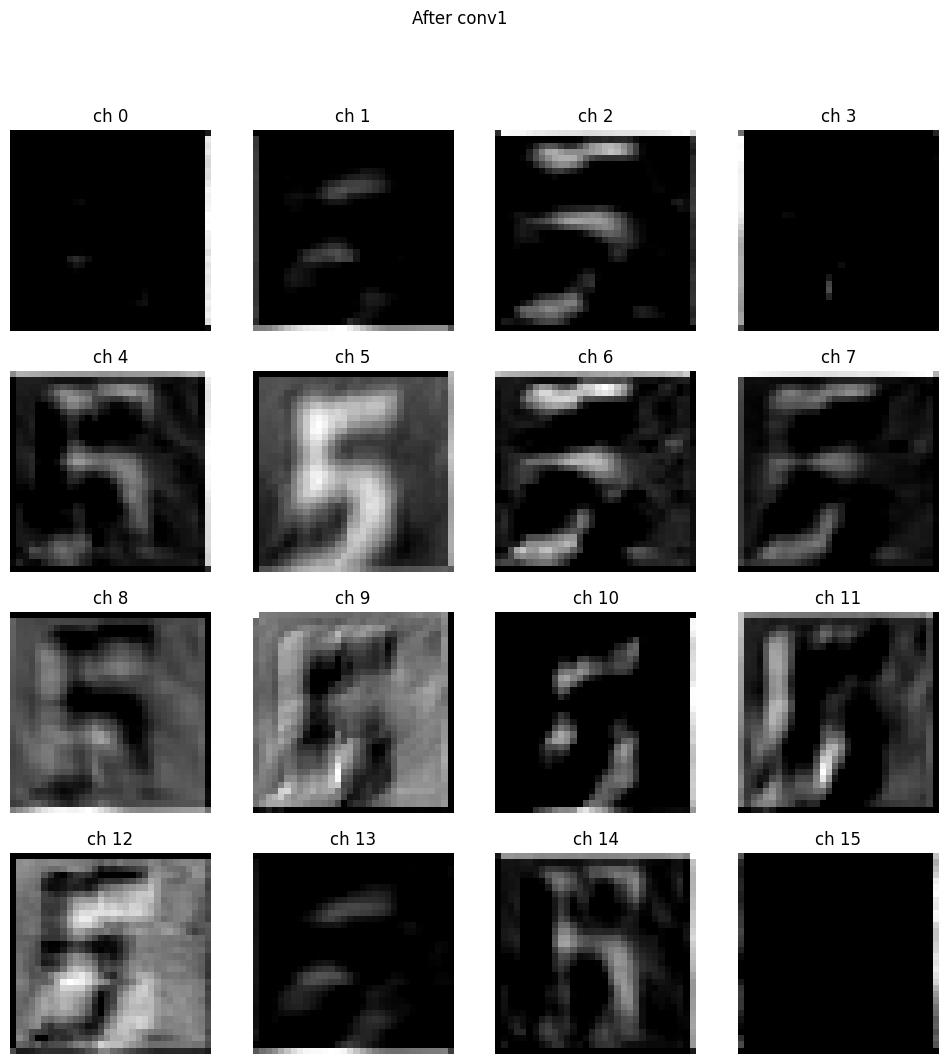

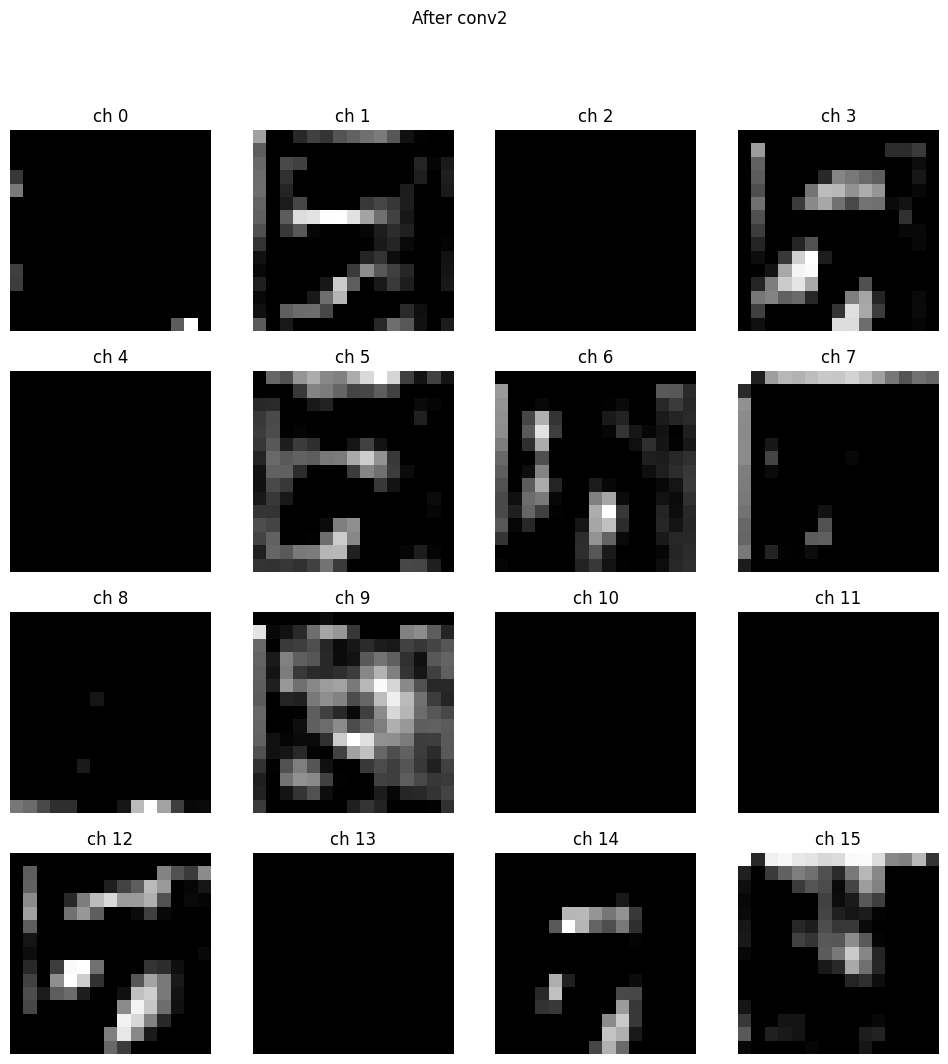

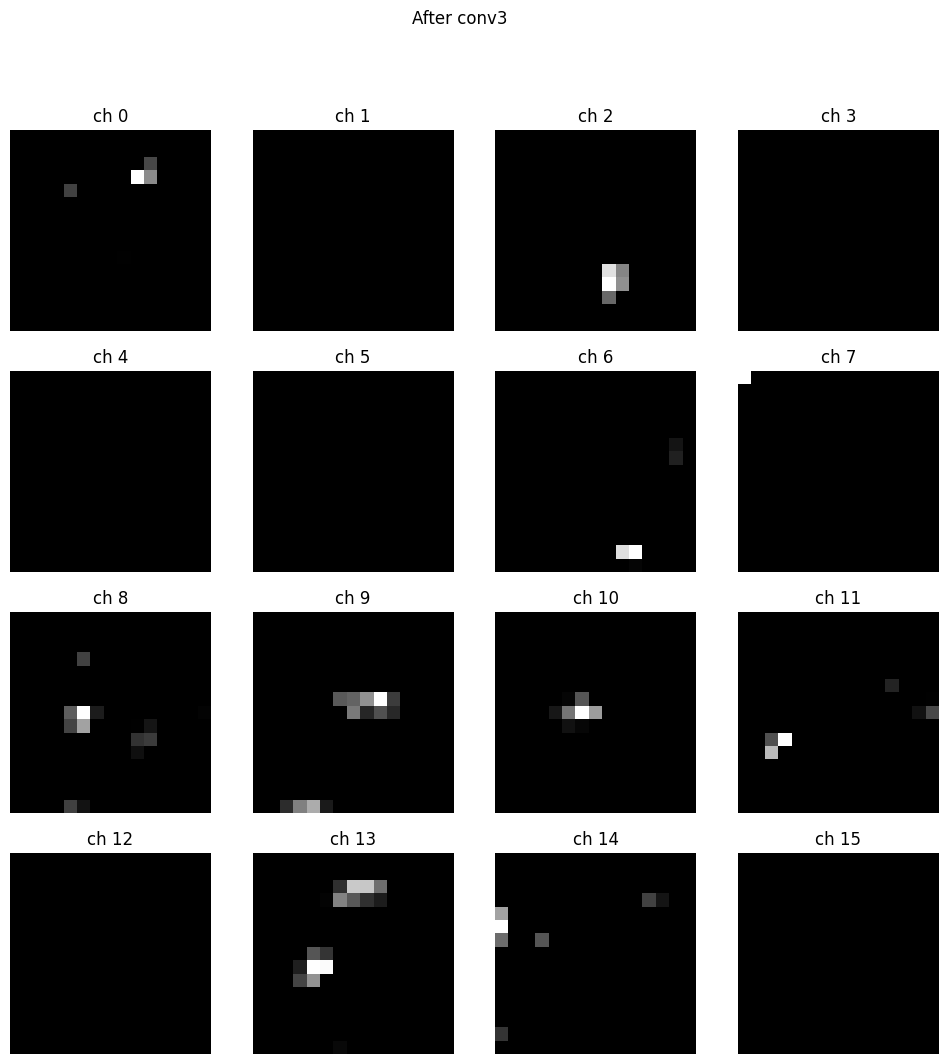

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

images, labels = next(iter(test_loader))   # תיקח batch
x = images[0:1].to(device)                 # תמונה אחת (shape: 1x3x32x32)

a1, a2, a3 = get_feature_maps(model, x)

show_feature_maps(a1, title="After conv1")
show_feature_maps(a2, title="After conv2")
show_feature_maps(a3, title="After conv3")


### Architecture Modification Experiment

Modify your `SVHN_CNN` model by removing or relocating different kinds of layers.

1. Propose two significant architectural changes.
2. Implement your modified models as
  - `SVHN_CNN_v2`
  - `SVHN_CNN_v3`
3. Train and evaluate both models using the same setup as the original.

In [ ]:
class SVHN_CNN_v2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),          # 32 -> 15

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),          # 15 -> 7

            nn.Dropout(p=0.3),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))   # (N,128,1,1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)  # (N,128)
        return self.classifier(x)


In [ ]:
class SVHN_CNN_v3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool1 = nn.MaxPool2d(3, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(3, 2)

        # מחשבים flatten_dim עם dummy input בגודל של התמונות שלך (SVHN = 32x32)
        with torch.no_grad():
            x = torch.zeros(1, 3, 32, 32)
            x = self.pool1(F.relu(self.conv1(x)))
            x = self.pool2(F.relu(self.conv2(x)))
            flatten_dim = x.flatten(1).shape[1]

        self.fc1 = nn.Linear(flatten_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [ ]:
# same setup as original:

criterion = nn.CrossEntropyLoss()

def train_and_eval(model_class, name, epochs=10):
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_model(model, train_loader, criterion, optimizer, device, num_epochs=epochs)
    test_acc = evaluate_model(model, test_loader, device)

    print(f"{name} test acc: {test_acc:.2f}%")
    return test_acc



In [ ]:
# Train & evaluate modified architectures (Question 1 – last part)

acc_v2 = train_and_eval(SVHN_CNN_v2, "SVHN_CNN_v2", epochs=10)
acc_v3 = train_and_eval(SVHN_CNN_v3, "SVHN_CNN_v3", epochs=10)

print("Summary:")
print(f"SVHN_CNN_v2 Test Accuracy: {acc_v2:.2f}%")
print(f"SVHN_CNN_v3 Test Accuracy: {acc_v3:.2f}%")


Epoch [1/10] Train Loss: 1.6876, Train Acc: 43.16%
Epoch [2/10] Train Loss: 1.1415, Train Acc: 64.68%
Epoch [3/10] Train Loss: 0.9008, Train Acc: 72.87%
Epoch [4/10] Train Loss: 0.7708, Train Acc: 77.00%
Epoch [5/10] Train Loss: 0.6873, Train Acc: 79.22%
Epoch [6/10] Train Loss: 0.6316, Train Acc: 80.95%
Epoch [7/10] Train Loss: 0.5902, Train Acc: 82.18%
Epoch [8/10] Train Loss: 0.5581, Train Acc: 83.13%
Epoch [9/10] Train Loss: 0.5316, Train Acc: 83.87%
Epoch [10/10] Train Loss: 0.5047, Train Acc: 84.65%
SVHN_CNN_v2 test acc: 85.64%
Epoch [1/10] Train Loss: 0.8211, Train Acc: 74.76%
Epoch [2/10] Train Loss: 0.4374, Train Acc: 87.44%
Epoch [3/10] Train Loss: 0.3552, Train Acc: 89.67%
Epoch [4/10] Train Loss: 0.3060, Train Acc: 91.04%
Epoch [5/10] Train Loss: 0.2700, Train Acc: 92.09%
Epoch [6/10] Train Loss: 0.2366, Train Acc: 93.17%
Epoch [7/10] Train Loss: 0.2134, Train Acc: 93.64%
Epoch [8/10] Train Loss: 0.1881, Train Acc: 94.50%
Epoch [9/10] Train Loss: 0.1681, Train Acc: 95.08%
E

## Question 2: The One Hundred Layers Tiramisu (45 Points)


In this question we explore the problem of **semantic segmentation**: assigning a class label to **every pixel** in an image.

We base our work on the paper:

> Jégou, S., Drozdzal, M., Vázquez, D., Romero, A., & Bengio, Y. (2017).  
> **The One Hundred Layers Tiramisu: Fully Convolutional DenseNets for Semantic Segmentation.**  
> *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition Workshops (CVPRW)*.  
> [[PDF link](https://arxiv.org/pdf/1611.09326.pdf)]


For those interested, I highly recommend reading the paper to expand your understanding of DenseNet-based architectures and generally in deep learning literature. That said, reading it is **not required** — the tools and concepts needed for this assignment are introduced gradually throughout the steps.

Our goal is to replicate the architecture of DenseNets described in the paper, aiming for comparable behaviour while using a **smaller variant** (e.g., DenseNet-67 instead of DenseNet-103) to ensure runtime feasibility on your GPUs.

We work with the **CamVid** dataset, which consists of urban driving scenes captured from a moving vehicle. Each image is paired with a pixel-wise annotation map indicating semantic classes such as road, sidewalk, building, sky, tree, fence, poles, traffic signs or lights, vehicles, pedestrians, and bicyclists.

Conceptually, semantic segmentation transforms an image into a **grid of classification tasks** — one small prediction problem per pixel — requiring the network to recognize objects and localize them throughout the scene.


### Data Loading & Preprocessing

Before building the model, we must ensure that the dataset is represented in a form a neural network can learn from.

Let:
- $X$ denote the RGB input images from CamVid.
- $Y$ denote the corresponding color-coded annotation masks, where each pixel encodes a semantic class via an RGB value.

The raw CamVid annotations contain **over 30 distinct colors**, including rare and fine-grained categories.  
To make learning tractable and consistent with common practice, we collapse these into a compact set of **11 semantic classes**, and assign all remaining labels to a single **void class**, which is ignored during training.

In this section we will:

1. Define or load the RGB-to-label mapping.
2. Convert each colored mask into a 2D array of integer class IDs.
3. Visualize sample inputs and their mapped labels to verify correctness.

With this mapping in place, segmentation becomes a **pixel-wise classification task** over the label space $\{0, \dots, C-1\}$, rather than operating directly on raw RGB annotation images.


We will use the **CamVid dataset**, which contains street-scene RGB images and their corresponding pixel-wise annotations.  
Please upload the provided `CamVid.zip` dataset to your own google drive. Then, run the following cells by mounting to your drive and unzipping the data.
The archive will be automatically extracted into `/content/CamVid/`.

> `CamVid.zip` is provided to you in `DL-HW2.zip`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/CamVid.zip"  # wherever you uploaded it
extract_root = "/content/drive/MyDrive/CamVid"

os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_root)

print("Extracted to Drive:", extract_root)
!ls "/content/drive/MyDrive/CamVid"

Extracted to Drive: /content/drive/MyDrive/CamVid
class_dict.csv	test	     train	   val
__MACOSX	test_labels  train_labels  val_labels


CamVid annotations are stored as **RGB color masks**, where each distinct color corresponds to a semantic category.  
To train a segmentation model, we must convert these colors into **integer class IDs**.

The mapping used here collapses ~32 original colors into **11 trainable categories** (Sky, Building, Road, etc.), with a separate **Void class** assigned label 255 and excluded from the loss.

Below we define:
- an RGB-to-label mapping,
- a PyTorch dataset class that:
  - reads images and masks,
  - applies cropping and flipping,
  - converts masks into numeric class IDs,
  - normalizes images.

In [ ]:
# Data Loading & Preprocessing

# Convert 32 -> 11 CamVid mapping: RGB -> label name
RGBLabel2LabelName = {
    (128, 128, 128): "Sky",

    (0,   128,  64): "Building",
    (128,   0,   0): "Building",
    (64,  192,   0): "Building",
    (64,    0,  64): "Building",
    (192,   0, 128): "Building",

    (192, 192, 128): "Pole",
    (0,     0,  64): "Pole",

    (128,  64, 128): "Road",
    (128,   0, 192): "Road",
    (192,   0,  64): "Road",

    (0,     0, 192): "Sidewalk",
    (64,  192, 128): "Sidewalk",
    (128, 128, 192): "Sidewalk",

    (128, 128,   0): "Tree",
    (192, 192,   0): "Tree",

    (192, 128, 128): "SignSymbol",
    (128, 128,  64): "SignSymbol",
    (0,    64,  64): "SignSymbol",

    (64,   64, 128): "Fence",

    (64,    0, 128): "Car",
    (64,  128, 192): "Car",
    (192, 128, 192): "Car",
    (192,  64, 128): "Car",
    (128,  64,  64): "Car",

    (64,   64,   0): "Pedestrian",
    (192, 128,  64): "Pedestrian",
    (64,    0, 192): "Pedestrian",
    (64,  128,  64): "Pedestrian",

    (0,   128, 192): "Bicyclist",
    (192,   0, 192): "Bicyclist",

    (0,     0,   0): "Void"
}

# Define the 11 train classes and the void index
TRAIN_CLASSES = [
    "Sky",
    "Building",
    "Pole",
    "Road",
    "Sidewalk",
    "Tree",
    "SignSymbol",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist"
]

LABEL_NAME_TO_ID = {name: i for i, name in enumerate(TRAIN_CLASSES)}
VOID_LABEL_NAME = "Void"
VOID_INDEX = 255


class CamVidDataset(Dataset):
    """
    CamVid dataset loader that:
    - reads RGB images from e.g. CamVid/train
    - reads RGB masks from e.g. CamVid/train_labels
    - uses the RGBLabel2LabelName mapping to:
        32+ RGB colors -> 11 train classes (0..10) + Void (255)
    - applies normalization and simple augmentations

    Output:
      image: float tensor (3, H, W), normalized (ImageNet stats)
      mask:  long tensor (H, W) with values in {0..10, 255}
             where 255 is the ignore_index for the loss.
    """

    def __init__(self,
                 image_dir,
                 mask_dir,
                 crop_size=(224, 224),
                 is_train=True):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.is_train = is_train
        self.crop_h, self.crop_w = crop_size

        # Collect image paths
        self.image_paths = sorted(
            glob(os.path.join(image_dir, "*.png")) +
            glob(os.path.join(image_dir, "*.jpg")) +
            glob(os.path.join(image_dir, "*.jpeg"))
        )
        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {image_dir}")

        # Build corresponding mask paths (same filename, different folder)
        self.mask_paths = []
        for p in self.image_paths:
            base = os.path.basename(p)
            name, ext = os.path.splitext(base)


            candidate = os.path.join(mask_dir, name + "_L" + ext)
            if os.path.exists(candidate):
                self.mask_paths.append(candidate)
            else:
                candidate2 = os.path.join(mask_dir, base)
                if not os.path.exists(candidate2):
                    raise FileNotFoundError(
                        f"Could not find mask for image {p}. "
                        f"Tried: {candidate} and {candidate2}"
                    )
                self.mask_paths.append(candidate2)

        # Build color -> train_id mapping from RGBLabel2LabelName
        self.num_classes = len(TRAIN_CLASSES)
        self.train_id_to_name = TRAIN_CLASSES
        self.void_index = VOID_INDEX

        self.color_to_train_id = {}
        for (r, g, b), label_name in RGBLabel2LabelName.items():
            if label_name == VOID_LABEL_NAME:
                # Void will be handled by default (everything starts as VOID_INDEX)
                continue
            train_id = LABEL_NAME_TO_ID[label_name]
            self.color_to_train_id[(r, g, b)] = train_id

        # Normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image & mask as numpy arrays
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")  # color-coded mask

        img = np.array(img, dtype=np.uint8)   # (H,W,3)
        mask = np.array(mask, dtype=np.uint8) # (H,W,3)

        # random data augmentation
        if self.is_train:
            img, mask = self.random_crop(img, mask, self.crop_h, self.crop_w)
            img, mask = self.random_horizontal_flip(img, mask)

        # Convert color mask -> class index mask (0..10, 255)
        class_mask = self.rgb_to_class_indices(mask)  # (H,W), int64

        # Convert image to tensor and normalize
        img = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0  # (3,H,W)
        img = (img - self.mean) / self.std

        class_mask = torch.from_numpy(class_mask).long()  # (H,W)

        return img, class_mask

    def rgb_to_class_indices(self, mask_rgb):
        """
        mask_rgb: (H,W,3) uint8
        returns: (H,W) int64 with values in {0..num_classes-1, void_index}

        Any pixel whose color is not in RGBLabel2LabelName or not in the 11
        train classes is assigned void_index (255), same idea as CamVidGray.
        """
        h, w, _ = mask_rgb.shape
        class_mask = np.full((h, w), fill_value=self.void_index, dtype=np.int64)

        # iterate over all known label colors
        for (r, g, b), train_id in self.color_to_train_id.items():
            matches = (
                (mask_rgb[:, :, 0] == r) &
                (mask_rgb[:, :, 1] == g) &
                (mask_rgb[:, :, 2] == b)
            )
            class_mask[matches] = train_id

        # Any remaining colors (including weird mislabels) stay as void_index
        return class_mask

    @staticmethod
    def random_crop(img, mask, crop_h, crop_w):
        """Randomly crop the same region from image and mask."""
        H, W, _ = img.shape
        if (H <= crop_h) or (W <= crop_w):
            # Fallback: center crop if image is smaller than the crop
            top = max(0, (H - crop_h) // 2)
            left = max(0, (W - crop_w) // 2)
        else:
            top = np.random.randint(0, H - crop_h + 1)
            left = np.random.randint(0, W - crop_w + 1)

        img_crop = img[top:top + crop_h, left:left + crop_w, :]
        mask_crop = mask[top:top + crop_h, left:left + crop_w, :]

        return img_crop, mask_crop

    @staticmethod
    def random_horizontal_flip(img, mask, p=0.5):
        """Randomly flip image and mask horizontally with probability p."""
        if np.random.rand() < p:
            img = np.ascontiguousarray(img[:, ::-1, :])   # flip width
            mask = np.ascontiguousarray(mask[:, ::-1, :])
        return img, mask

We now instantiate our dataset class over the train/validation splits and wrap them with PyTorch `DataLoader`s for batching.

We verify:
- tensor shapes,
- expected number of classes,
- that label values fall within `{0..10, 255}`.

In [ ]:
# Base directory
base_dir = "/content/drive/MyDrive/CamVid"

train_images = f"{base_dir}/train"
train_masks  = f"{base_dir}/train_labels"

val_images   = f"{base_dir}/val"
val_masks    = f"{base_dir}/val_labels"

test_images  = f"{base_dir}/test"
test_masks   = f"{base_dir}/test_labels"

# Create datasets
train_dataset = CamVidDataset(
    image_dir=train_images,
    mask_dir=train_masks,
    crop_size=(224, 224),
    is_train=True
)

val_dataset = CamVidDataset(
    image_dir=val_images,
    mask_dir=val_masks,
    crop_size=(224, 224),
    is_train=False
)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=3, shuffle=False, num_workers=2)

# Quick sanity check: shapes + labels
imgs, masks = next(iter(train_loader))
print("Images:", imgs.shape)   # (B,3,H,W)
print("Masks:", masks.shape)   # (B,H,W)
print("Num classes:", train_dataset.num_classes)
print("Unique labels in this batch:", torch.unique(masks))

Images: torch.Size([3, 3, 224, 224])
Masks: torch.Size([3, 224, 224])
Num classes: 11
Unique labels in this batch: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9, 255])


To ensure that preprocessing worked as expected, we decode the class IDs back into colors and visualize:
- the input RGB image,
- the processed 11-class segmentation mask,
- an overlay.

This provides a quick visual confirmation that label mapping and crops are applied correctly.

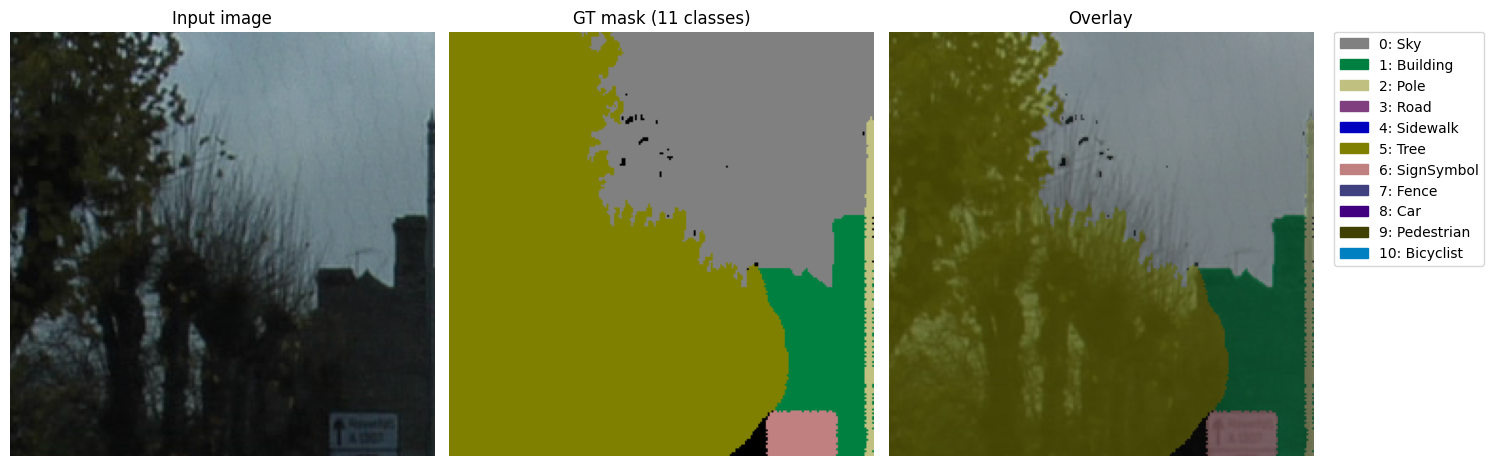

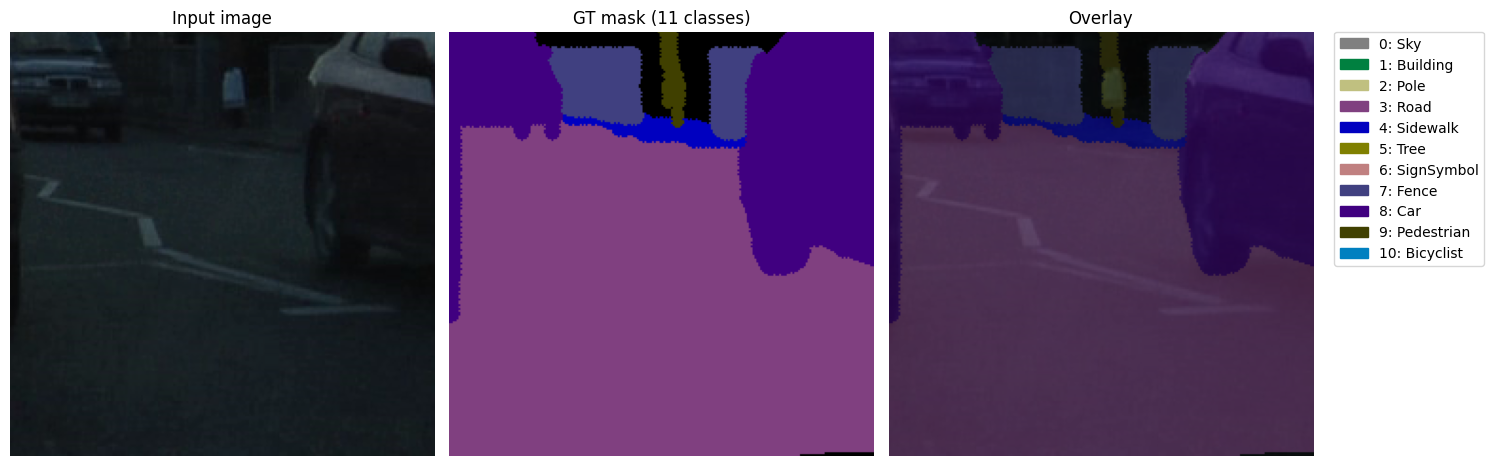

In [ ]:
# Build a display color for each of the 11 train classes:
# take the first RGB that maps to that label.
import matplotlib.patches as mpatches
TRAIN_ID_TO_COLOR = {}
for (r, g, b), label_name in RGBLabel2LabelName.items():
    if label_name == VOID_LABEL_NAME:
        continue
    train_id = LABEL_NAME_TO_ID[label_name]
    if train_id not in TRAIN_ID_TO_COLOR:
        TRAIN_ID_TO_COLOR[train_id] = (r, g, b)


def decode_class_mask(class_mask, train_id_to_color, void_index=VOID_INDEX):
    """
    class_mask: (H,W) int64 in {0..C-1, void_index}
    returns: (H,W,3) uint8 color mask for visualization
    """
    h, w = class_mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for train_id, color in train_id_to_color.items():
        color_mask[class_mask == train_id] = np.array(color, dtype=np.uint8)

    # void pixels stay black (0,0,0);
    return color_mask


def visualize_camvid_sample(dataset, idx=0):
    """
    Show:
      - input image
      - merged 11-class mask
      - overlay + legend (class key)
    """
    img, mask = dataset[idx]  # img: normalized tensor, mask: (H,W) long

    # Denormalize for display
    img_np = img.clone()
    img_np = (img_np * dataset.std + dataset.mean).clamp(0, 1)
    img_np = img_np.numpy().transpose(1, 2, 0)  # (H,W,3), [0,1]

    mask_np = mask.numpy()
    color_mask = decode_class_mask(mask_np, TRAIN_ID_TO_COLOR, VOID_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_np)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(color_mask)
    axes[1].set_title("GT mask (11 classes)")
    axes[1].axis("off")

    axes[2].imshow(img_np)
    axes[2].imshow(color_mask, alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    # Legend / key
    patches = [
        mpatches.Patch(
            color=np.array(TRAIN_ID_TO_COLOR[i]) / 255.0,
            label=f"{i}: {TRAIN_CLASSES[i]}"
        )
        for i in range(len(TRAIN_CLASSES))
    ]
    axes[2].legend(handles=patches, bbox_to_anchor=(1.05, 1.0),
                   loc="upper left", borderaxespad=0.)

    plt.tight_layout()
    plt.show()


# Try a couple of samples
visualize_camvid_sample(train_dataset, idx=0)
visualize_camvid_sample(train_dataset, idx=10)

### Network Architecture Overview

We now design the architecture of our DenseNet model — a fully convolutional encoder–decoder network tailored for semantic segmentation.

<p align="center">
  <img src="https://raw.githubusercontent.com/SimJeg/FC-DenseNet/cf2375bf9f6ed20ba029a5ee540261aad89732d5/DenseNet.jpg" width="650"/>
</p>

Conceptually, the network processes the image through a **downsampling path** (encoder), reaches a compressed representation (bottleneck), and then reconstructs a dense prediction map through an **upsampling path** (decoder). Lateral skip connections link encoder features to their corresponding decoder levels, ensuring fine spatial detail is preserved.

The architecture is built from the following components:

**(a) Dense Layer**

**(b) Dense Block**

**(c) Transition Down**

**(d) Transition Up**

**(e) Bottleneck Block**

**(f) Final Classifier**

We next implement each component in modular form and assemble them into a complete FC-DenseNet for CamVid segmentation.


#### **(a) Dense Layer**

The basic computational unit in DenseNet is the **dense layer**.  
Each layer receives as input **all previous feature maps** in the block, applies:

$$
\text{BN} \rightarrow \text{ReLU} \rightarrow 3 \times 3 \text{Conv}
$$

and produces `k` new feature maps (the **growth rate**).  
These outputs are concatenated with the input along the channel axis.


In [ ]:
class DenseLayer(nn.Module):
    """
    BN -> ReLU -> 3x3 Conv -> Dropout,
    then concatenate input and output feature maps.
    """
    def __init__(self, in_channels, growth_rate, drop_prob=0.2):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        self.dropout = nn.Dropout2d(p=drop_prob)

    def forward(self, x):
        out = self.bn(x)
        out = self.relu(out)
        out = self.conv(out)
        out = self.dropout(out)
        return torch.cat([x, out], dim=1)  # Concatenate input with new features

#### **(b) Dense Block**  


A dense block stacks several dense layers sequentially.  
Each layer receives **all feature maps from previous layers** and contributes new ones:

$$
C_{\text{out}} = C_{\text{in}} + L \cdot k
$$

<p align="center">
  <img src="https://raw.githubusercontent.com/SimJeg/FC-DenseNet/master/DenseBlock.jpg" width="300" height="600"/>
</p>

This connectivity pattern promotes feature reuse, stabilizes gradients, and forms the core building unit of our network.


In [ ]:
class DenseBlock(nn.Module):
    """
    A sequence of DenseLayer modules.
    Input channels grow by `growth_rate` at each layer.
    """
    def __init__(self, in_channels, num_layers, growth_rate, drop_prob=0.2):
        super(DenseBlock, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            layer_in_channels = in_channels + i * growth_rate
            self.layers.append(DenseLayer(layer_in_channels, growth_rate, drop_prob))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

#### **(c) Transition Down**


At the end of each encoder stage, we reduce spatial resolution:

$$
\text{BN} \rightarrow \text{ReLU} \rightarrow 1\times1\text{ Conv} \rightarrow \text{Dropout} \rightarrow \text{MaxPool}(2)
$$

This halves width and height while keeping channels unchanged.


In [ ]:
class TransitionDown(nn.Module):
    """
    BN + ReLU + 1x1 Conv + Dropout + MaxPool(2x2)
    """
    def __init__(self, in_channels, drop_prob=0.2):
        super(TransitionDown, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=1, bias=False)
        self.dropout = nn.Dropout2d(p=drop_prob)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        out = self.bn(x)
        out = self.relu(out)
        out = self.conv(out)
        out = self.dropout(out)
        out = self.pool(out)
        return out

#### **(d) Transition Up**  


In the decoder, we restore resolution using learned upsampling via transposed convolution:

$$
\text{ConvTranspose}(3 \times 3, \text{stride}=2)
$$

which doubles spatial resolution before concatenation with skip features.


In [ ]:
class TransitionUp(nn.Module):
    """
    Bilinear upsampling + Conv instead of transposed conv (reduces checkerboard artifacts)
    """
    def __init__(self, in_channels, out_channels):
        super(TransitionUp, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        # Bilinear upsample then conv (smoother than transposed conv)
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.conv(x)
        return x

#### **(e) Bottleneck Block**


At the deepest level, the network operates at the lowest spatial resolution but highest channel width.

A final dense block processes this information before reconstruction begins in the decoder.


### Our FC-DenseNet-lite Architecture

We implement a compact FC-DenseNet architecture inspired by *The One Hundred Layers Tiramisu*.
All convolutional **dense layers** use growth rate $k = 16$. At each dense block:

- Input has $m$ feature maps.
- The block has $n$ layers.
- Each layer adds $k$ new feature maps.
- The output of the block therefore has $m + n \cdot k$ feature maps (because we concatenate all newly created features with the input).

Transition Down (TD) blocks keep the number of channels $m$ but downsample in space via 2×2 max pooling.
Transition Up (TU) blocks use a 3×3 transposed convolution with stride 2 to upsample.

Our **homework architecture ("FC-DenseNet-lite")** is defined as follows:

- Input: RGB image, $m = 3$
- Initial 3×3 convolution: $m = 48$

</br>

**Downsampling path (encoder)**

- Dense Block 1: 4 layers  
  $m = 48 + 4 \cdot 16 = 112$  
  + Transition Down → spatial size /2, channels stay 112
- Dense Block 2: 5 layers  
  $m = 112 + 5 \cdot 16 = 192$  
  + Transition Down → channels 192
- Dense Block 3: 7 layers  
  $m = 192 + 7 \cdot 16 = 304$  
  + Transition Down → channels 304
- Dense Block 4: 10 layers  
  $m = 304 + 10 \cdot 16 = 464$  
  + Transition Down → channels 464

</br>


**Bottleneck**

- Dense Block (bottleneck): 15 layers  
  $m = 464 + 15 \cdot 16 = 704$

</br>


**Upsampling path (decoder)**

At each level, we:
1. Apply a Transition Up (TU) to upsample the current feature maps.
2. Concatenate with the skip connection from the corresponding encoder level.
3. Apply a dense block at that resolution.

We use symmetric numbers of layers in the decoder:

- TU from bottleneck + skip from Dense Block 4 $\to$ Dense Block (10 layers)
- TU + skip from Dense Block 3 $\to$ Dense Block (7 layers)
- TU + skip from Dense Block 2 $\to$ Dense Block (5 layers)
- TU + skip from Dense Block 1 $\to$ Dense Block (4 layers)


</br>

**Final classifier**

- 1×1 convolution maps the decoder output to $C = 11$ class logits per pixel.

> We call network `FC-DenseNet67` which is a smaller version of `FC-DenseNet103`, the architecture used in the paper.

In [ ]:
class FCDenseNet(nn.Module):
    """
    Fully Convolutional DenseNet for semantic segmentation.
    Uses:
      - initial 3x3 conv
      - sequence of DenseBlock + TransitionDown (encoder)
      - bottleneck DenseBlock
      - sequence of TransitionUp + DenseBlock with skip connections (decoder)
      - final 1x1 conv to class logits
    """
    def __init__(self, in_channels=3, n_classes=11, growth_rate=16, drop_prob=0.2):
            super(FCDenseNet, self).__init__()

            # Architecture config: [encoder layers], bottleneck, [decoder layers]
            down_layers = [4, 5, 7, 10]
            bottleneck_layers = 15
            up_layers = [10, 7, 5, 4]

            self.growth_rate = growth_rate

            # Initial convolution: 3 -> 48
            self.init_conv = nn.Conv2d(in_channels, 48, kernel_size=3, padding=1, bias=False)

            # ============ ENCODER ============
            self.down_blocks = nn.ModuleList()
            self.trans_downs = nn.ModuleList()
            self.skip_channels = []

            cur_channels = 48
            for n_layers in down_layers:
                # Dense block
                self.down_blocks.append(DenseBlock(cur_channels, n_layers, growth_rate, drop_prob))
                cur_channels = cur_channels + n_layers * growth_rate
                self.skip_channels.append(cur_channels)
                # Transition down
                self.trans_downs.append(TransitionDown(cur_channels, drop_prob))

            # ============ BOTTLENECK ============
            self.bottleneck = DenseBlock(cur_channels, bottleneck_layers, growth_rate, drop_prob)
            bottleneck_out = bottleneck_layers * growth_rate  # Only new features go to decoder

            # ============ DECODER ============
            self.trans_ups = nn.ModuleList()
            self.up_blocks = nn.ModuleList()

            prev_channels = bottleneck_out
            for i, n_layers in enumerate(up_layers):
                # Transition up
                self.trans_ups.append(TransitionUp(prev_channels, prev_channels))
                # After concat with skip connection
                skip_ch = self.skip_channels[-(i+1)]
                combined = prev_channels + skip_ch
                # Dense block
                self.up_blocks.append(DenseBlock(combined, n_layers, growth_rate, drop_prob))
                prev_channels = n_layers * growth_rate

            # ============ FINAL CLASSIFIER ============
            self.final_conv = nn.Conv2d(prev_channels, n_classes, kernel_size=1)
    def forward(self, x):
            # Initial conv
            out = self.init_conv(x)

            # Encoder with skip connections
            skips = []
            for down_block, trans_down in zip(self.down_blocks, self.trans_downs):
                out = down_block(out)
                skips.append(out)
                out = trans_down(out)

            # Bottleneck - only pass NEW features to decoder
            bottleneck_in = out
            out = self.bottleneck(out)
            # Extract only new features (remove input channels)
            out = out[:, bottleneck_in.size(1):, :, :]

            # Decoder with skip connections
            for i, (trans_up, up_block) in enumerate(zip(self.trans_ups, self.up_blocks)):
                out = trans_up(out)
                skip = skips[-(i+1)]
                # Handle size mismatch if any
                if out.shape[2:] != skip.shape[2:]:
                    out = F.interpolate(out, size=skip.shape[2:], mode='bilinear', align_corners=True)
                out = torch.cat([out, skip], dim=1)
                out = up_block(out)
                # Extract only new features for next level
                out = out[:, -up_block.layers[-1].conv.out_channels * len(up_block.layers):, :, :]

            # Final classification
            out = self.final_conv(out)
            return out



**Sanity Check!**

Before training, we verify that the model:

- accepts a tensor of shape `(B, 3, H, W)`,
- returns logits of shape `(B, C, H, W)` matching the number of classes.

This ensures that channel propagation, skip concatenation, and upsampling were implemented correctly.


In [ ]:
model = FCDenseNet(in_channels=3, n_classes=len(TRAIN_CLASSES), growth_rate=16)
x = torch.randn(1, 3, 224, 224)
y = model(x)
print("Output shape:", y.shape)  # expected: (1, 11, 224, 224)


Output shape: torch.Size([1, 11, 224, 224])


**Answer the following Questions:**

<font color="red">1. Why do segmentation networks need spatial priors that classification networks can ignore?

Classification networks only need to output a single label for the entire image, so they can use global average pooling to collapse all spatial information into a single vector. Segmentation networks must produce a prediction for every pixel, requiring them to preserve and recover spatial structure throughout the network. They need spatial priors (like locality assumptions in convolutions, and encoder-decoder structures) to maintain correspondence between input pixel locations and output predictions.</font>  



<font color="red">2. What changes architecturally when we move from "what is in the image?" to "where is it?"

Key architectural changes include:   
(1) Removing fully connected layers that destroy spatial information;    
(2) Adding an upsampling/decoder path to recover full input resolution;   
(3) Introducing skip connections to pass fine-grained spatial details from encoder to decoder;   
(4) Using transposed convolutions or bilinear upsampling instead of pooling-only architectures;  
(5) Output becomes a dense prediction map (H×W×C) instead of a single class vector.
</font>

<font color="red">3. What failure mode would you expect if skip connections were removed from Tiramisu?  

Without skip connections, the network would produce blurry, poorly localized segmentation masks. The decoder would only have access to the highly compressed bottleneck features, losing fine spatial details like object boundaries, thin structures (poles, signs), and small objects (pedestrians). The model would struggle to precisely delineate edges and would tend to produce "blobby" predictions that roughly indicate object presence but lack sharp boundaries.
</font>  

<font color="red">4. How do skip connections influence gradient flow and spatial detail recovery?

Gradient flow: Skip connections create shorter paths from the loss back to early layers, mitigating vanishing gradients and allowing deeper networks to train effectively. Gradients can bypass the bottleneck and flow directly to encoder layers. Spatial detail recovery: Skip connections transfer high-resolution feature maps from the encoder directly to the decoder, providing fine-grained information (edges, textures, precise boundaries) that would otherwise be lost during downsampling. This enables the decoder to combine semantic understanding (from deep features) with spatial precision (from skip features).
</font>


### Evaluation & Training

We now train our network on CamVid and assess its performance. Before launching training, we first define **evaluation metrics** suited for semantic segmentation, followed by the standard training procedure we are used to.

#### Evaluation Metrics



Semantic segmentation predictions assign a class to **every pixel**.  
Therefore, our evaluation must measure how well the network labels individual pixels and how well it segments regions belonging to different semantic categories.

**1. Pixel-wise Accuracy**

Pixel accuracy measures the fraction of correctly classified pixels:

$$
\text{PixelAcc} =
\frac{\sum_{(i,j)} \mathbf{1}\left[ \hat{Y}_{ij} = Y_{ij} \right]}
     {\sum_{(i,j)} 1},
$$

where $\hat{Y}_{ij}$ is the predicted label and $Y_{ij}$ is the ground truth at pixel $(i,j)$.

This metric is intuitive and easy to interpret, but can be misleading in imbalanced datasets:
large regions like “road” or “sky” dominate, masking poor performance on rare classes (e.g., pedestrians or signs).

</br>
</br>

**2. Intersection over Union (IoU)**

IoU evaluates segmentation quality by comparing overlap between prediction and ground truth.

For a given class $c$, IoU is:

$$
\text{IoU}_c =
\frac{
|\{\hat{Y} = c\} \cap \{Y = c\}|
}{
|\{\hat{Y} = c\} \cup \{Y = c\}|
}.
$$

IoU penalizes:

- over-segmentation (predicting class $c$ where it does not exist), and  
- under-segmentation (missing regions belonging to class $c$).

To evaluate the entire model, we compute **mean IoU (mIoU)**:

$$
\text{mIoU} = \frac{1}{C}\sum_{c=1}^C \text{IoU}_c,
$$

where $C$ is the number of semantic classes.  
mIoU treats **all classes equally**, even rare ones, making it a standard research metric for segmentation benchmarks including CamVid.

In [ ]:
def pixel_accuracy(pred, target, ignore_index=255):
    """
    Compute pixel-wise accuracy, ignoring void pixels.
    pred: (N, H, W) predicted class indices
    target: (N, H, W) ground truth class indices
    """
    valid = (target != ignore_index)
    correct = ((pred == target) & valid).sum().float()
    total = valid.sum().float()
    return correct / total if total > 0 else torch.tensor(0.0)


def intersection_and_union(pred, target, num_classes, ignore_index=255):
    """
    Compute intersection and union for each class.
    Returns:
        intersection: (num_classes,) tensor
        union: (num_classes,) tensor
    """
    pred = pred.view(-1)
    target = target.view(-1)

    # Mask out ignore_index
    valid = (target != ignore_index)
    pred = pred[valid]
    target = target[valid]

    intersection = torch.zeros(num_classes)
    union = torch.zeros(num_classes)

    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        intersection[cls] = (pred_cls & target_cls).sum().float()
        union[cls] = (pred_cls | target_cls).sum().float()

    return intersection, union

#### Training

We train the network using a **pixel-wise cross-entropy loss**, treating segmentation as per-pixel classification.  
Pixels belonging to the “void” class (255) are ignored:

$$
\mathcal{L} = -\frac{1}{N} \sum_{(i,j)\;|\;Y_{ij}\neq 255}
\log p\left(\, Y_{ij} \mid X \, \right).
$$

Following the original FC-DenseNet paper:

- We use **RMSProp** as the optimizer.
- We include **weight decay (L2 regularization)** to encourage small parameter norms and improve stability.

The RMSProp update maintains a moving average of squared gradients $v$ and performs:

$$
\theta \leftarrow \theta - \alpha \cdot \frac{
\nabla_\theta \mathcal{L}
}{
\sqrt{v + \epsilon}
},
$$

which adaptively scales learning rates per parameter — particularly useful in deep architectures like DenseNets.



**Training Procedure:**

We train the network end-to-end over multiple epochs:

1. Read a mini-batch of input images and ground-truth masks.
2. Forward pass through `FCDenseNet`.
3. Compute loss using cross-entropy (ignoring void pixels).
4. Backpropagate gradients.
5. Update weights using RMSProp.
6. Accumulate accuracy and IoU statistics.
7. Validate periodically to observe generalization.

We repeat this process for 85 epochs, monitoring loss, pixel accuracy, and mIoU to evaluate convergence.

In [ ]:
# Training setup
num_epochs = 100  # Increased
num_classes = len(TRAIN_CLASSES)

model = FCDenseNet(in_channels=3, n_classes=len(TRAIN_CLASSES), growth_rate=16).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.RMSprop(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# Track best model
best_val_miou = 0.0
patience = 20  # Stop if no improvement for 20 epochs
patience_counter = 0

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    train_loss = 0.0
    train_inter = torch.zeros(num_classes)
    train_union = torch.zeros(num_classes)
    train_correct, train_total = 0, 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if outputs.shape[2:] != masks.shape[1:]:
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=True)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)

        inter, uni = intersection_and_union(preds.cpu(), masks.cpu(), num_classes)
        train_inter += inter
        train_union += uni

        valid = (masks != 255)
        train_correct += ((preds == masks) & valid).sum().item()
        train_total += valid.sum().item()

    scheduler.step()

    train_loss /= len(train_loader)
    train_iou = train_inter / (train_union + 1e-10)
    train_miou = train_iou[train_union > 0].mean().item()
    train_acc = train_correct / train_total

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_inter = torch.zeros(num_classes)
    val_union = torch.zeros(num_classes)
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            if outputs.shape[2:] != masks.shape[1:]:
                outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=True)

            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)

            inter, uni = intersection_and_union(preds.cpu(), masks.cpu(), num_classes)
            val_inter += inter
            val_union += uni

            valid = (masks != 255)
            val_correct += ((preds == masks) & valid).sum().item()
            val_total += valid.sum().item()

    val_loss /= len(val_loader)
    val_iou = val_inter / (val_union + 1e-10)
    val_miou = val_iou[val_union > 0].mean().item()
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train mIoU={train_miou:.4f}, Train Acc={train_acc:.4f}")
    print(f"          Val Loss={val_loss:.4f}, Val mIoU={val_miou:.4f}, Val Acc={val_acc:.4f}")

    # --- Save best model ---
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved! (Val mIoU: {val_miou:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement for {patience_counter} epochs")

    # --- Early stopping ---
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break

# Load best model for evaluation
print(f"\nLoading best model (Val mIoU: {best_val_miou:.4f})")
model.load_state_dict(torch.load('best_model.pth'))

Epoch 1/100 [Val]: 100%|██████████| 34/34 [00:10<00:00,  3.37it/s]


Epoch 1: Train Loss=2.3019, Train mIoU=0.1055, Train Acc=0.3824
          Val Loss=1.2573, Val mIoU=0.1601, Val Acc=0.5818
  ✓ New best model saved! (Val mIoU: 0.1601)


Epoch 2/100 [Val]: 100%|██████████| 34/34 [00:09<00:00,  3.41it/s]


Epoch 2: Train Loss=1.5834, Train mIoU=0.1438, Train Acc=0.4724
          Val Loss=1.2694, Val mIoU=0.1770, Val Acc=0.5570
  ✓ New best model saved! (Val mIoU: 0.1770)


Epoch 3/100 [Val]: 100%|██████████| 34/34 [00:10<00:00,  3.40it/s]


...

Epoch 99/100 [Val]: 100%|██████████| 34/34 [00:10<00:00,  3.35it/s]


Epoch 99: Train Loss=0.8154, Train mIoU=0.2913, Train Acc=0.7283
          Val Loss=0.6820, Val mIoU=0.3359, Val Acc=0.7888
  No improvement for 8 epochs


Epoch 100/100 [Val]: 100%|██████████| 34/34 [00:10<00:00,  3.37it/s]


Epoch 100: Train Loss=0.8567, Train mIoU=0.2854, Train Acc=0.7232
          Val Loss=0.6604, Val mIoU=0.3362, Val Acc=0.7938
  No improvement for 9 epochs

Loading best model (Val mIoU: 0.3470)


<All keys matched successfully>

Beyond numerical metrics, it is important to **visually inspect** the model’s predictions. In semantic segmentation, this usually means comparing:

1. the input RGB image,
2. the **ground-truth** segmentation mask,
3. the **predicted** segmentation mask.

By looking at these side by side, you can quickly see which classes the model recognizes well, where it struggles, typical failure modes.

Sample a few Images from the test set, and visualize them in comparison to the ground truth and your own prediction.


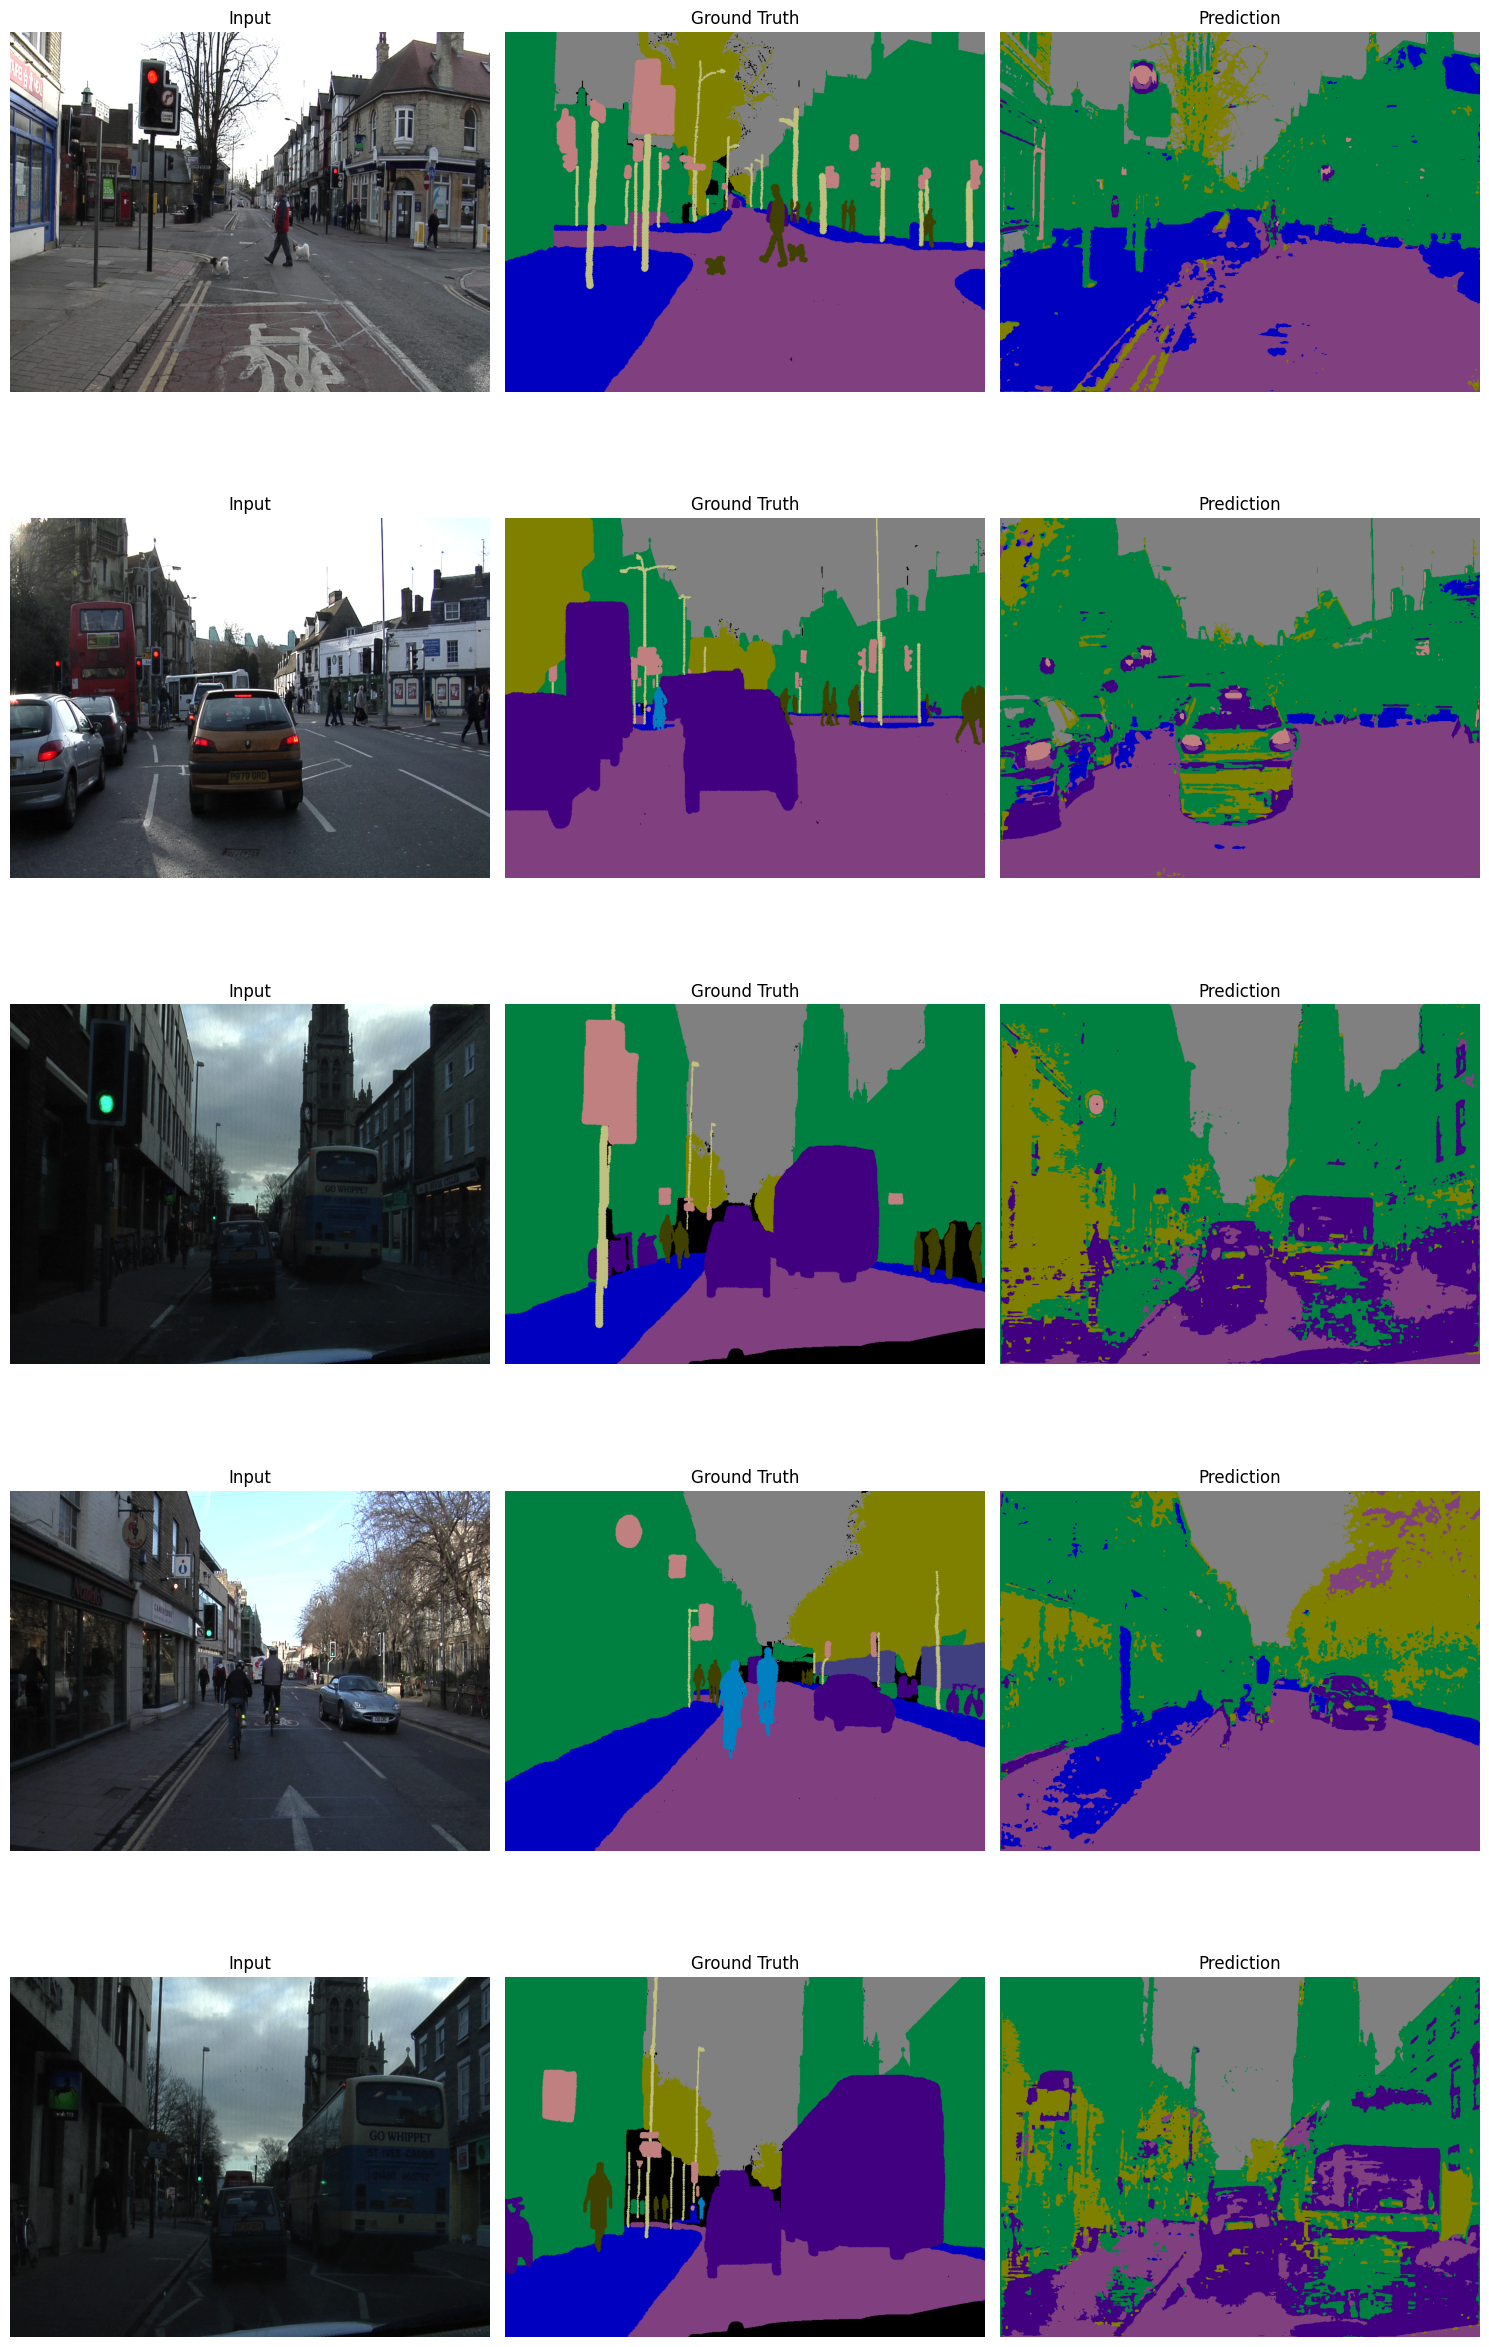

In [ ]:
# TODO: Implement
import matplotlib.patches as mpatches

def visualize_predictions(model, dataset, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))

    indices = random.sample(range(len(dataset)), num_samples)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, mask = dataset[idx]
            img_input = img.unsqueeze(0).to(device)

            output = model(img_input)
            if output.shape[2:] != mask.shape:
                output = F.interpolate(output, size=mask.shape, mode='bilinear', align_corners=True)
            pred = output.argmax(dim=1).squeeze(0).cpu().numpy()

            # Denormalize image
            img_np = (img * dataset.std + dataset.mean).clamp(0,1).numpy().transpose(1,2,0)
            mask_np = mask.numpy()

            # Decode masks to colors
            gt_color = decode_class_mask(mask_np, TRAIN_ID_TO_COLOR, VOID_INDEX)
            pred_color = decode_class_mask(pred, TRAIN_ID_TO_COLOR, VOID_INDEX)

            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title("Input")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(gt_color)
            axes[i, 1].set_title("Ground Truth")
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred_color)
            axes[i, 2].set_title("Prediction")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Create test dataset and visualize
test_dataset = CamVidDataset(
    image_dir=test_images,
    mask_dir=test_masks,
    crop_size=(224, 224),
    is_train=False
)
visualize_predictions(model, test_dataset, num_samples=5)

**Answer the following Questions:**

<font color="red">1. Do the errors your model makes seem semantic (wrong class) or spatial (wrong localization)?  

The errors are primarily spatial (wrong localization). The model correctly identifies the major semantic regions - sky appears gray, road appears purple, trees appear green/yellow, and buildings appear in the right areas. However, the boundaries between classes are noisy and imprecise, there is visible "bleeding" where classes mix at edges, and fine-grained structures (poles, signs, pedestrians) are poorly delineated. The predictions lack the smooth, crisp boundaries seen in the ground truth masks.
</font>  


<font color="red">2. Which component of the architecture most likely causes that type of error?  
  
  The decoder path and the limited capacity of skip connections are most likely responsible. While skip connections help recover spatial information, the features passed from encoder to decoder still lose high-frequency details during downsampling (4 pooling operations reduce resolution by 16×). The decoder dense blocks must reconstruct fine boundaries from this compressed information, which is inherently lossy. Additionally, the small crop size (224×224) during training limits the model's ability to learn long-range spatial context.</font>   
    

<font color="red">3. If you could change one design choice to address it, what would you alter?  
  
  We would add CRF (Conditional Random Field) post-processing to refine the segmentation boundaries. CRF considers pixel color similarity and spatial proximity to smooth predictions while preserving sharp edges. Alternatively, We could increase the crop size during training (e.g., 320×320 or full resolution) to give the model more spatial context, though this requires more GPU memory. Another option is to use multi-scale inference - running the model at multiple image scales and averaging predictions to improve robustness.</font>
